# Ablations

In this notebook, we investigate the different components of performance-based deep active learning, which are:
1. Batch Selection
2. Look-Ahead
3. Performance Estimation
4. Retraining

In [1]:
!rsync -avz cluster.ies:/mnt/work/dhuseljic/experiments/mlflow/perf_dal /home/dhuseljic/mlflow

import os 
import mlflow
import torch
import numpy as np
import pylab as plt
import pandas as pd
import matplotlib
from datetime import datetime
from collections import defaultdict

os.makedirs('plots', exist_ok=True)
matplotlib.rcParams['figure.figsize'] = (4, 3)
torch.set_grad_enabled(False)


def filter_by_date(runs, year, month, day):
    filtered_runs = []
    for run in runs:
        start_time = datetime.fromtimestamp(run.info.start_time / 1000) # in ms
        filter_time = datetime(year, month, day)
        if start_time > filter_time:
            filtered_runs.append(run)
    return filtered_runs

receiving incremental file list

sent 25 bytes  received 111 bytes  272.00 bytes/sec
total size is 76,247,040  speedup is 560,640.00


## Batch Selection

In [ ]:
dataset = 'cifar10'
exp_name = 'batch_selection_v2'
uri = 'sqlite:////home/dhuseljic/mlflow/perf_dal/optimal.db' 

runs = []
client = mlflow.tracking.MlflowClient(tracking_uri=uri)

# experiment_id = client.get_experiment_by_name('optimal_v3').experiment_id
# query_list = [f"parameter.al.strategy = 'random'", f"parameter.dataset_name= '{dataset}'",]
# runs_random = client.search_runs(experiment_ids=experiment_id, filter_string=' and '.join(query_list))
# runs.extend(runs_random)

experiment_id = client.get_experiment_by_name(exp_name).experiment_id
query_list = [
    f"parameter.al.strategy = 'optimal'",
    f"parameter.dataset_name = '{dataset}'", 
    f"parameter.al.optimal.num_batches= '90'", 
]
runs_optimal = client.search_runs(experiment_ids=experiment_id, filter_string=' and '.join(query_list))
runs.extend(runs_optimal)

runs = filter_by_date(runs, 2024, 10, 24)
print('Found {} experiments'.format(len(runs)))

Found 40 experiments


In [27]:
# Adapt runs 
for run in runs:
    al_strat = run.data.params['al.strategy']
    if al_strat == 'optimal':
        batch_types = eval(run.data.params['al.optimal.batch_types'])
        batch_types = [b.capitalize() for b in batch_types]
        name = f"{'+'.join(batch_types)} Batches"
        run.data.params['al.strategy'] = name
        # run.data.params['al.strategy'] = 'diverse'

runs_per_strat = defaultdict(list)
acc_curves = defaultdict(list)
for run in runs:
    key = run.data.params['al.strategy']
    runs_per_strat[key].append(run)
    acc_curves[key].append([m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')])

for key in  acc_curves:
    print(f"{key:40}: {len(acc_curves[key]):3}")

random                                  :  20
Random+Diverse+Uncertain Batches        :  20


In [ ]:
acq_size = int(runs_per_strat['random'][0].data.params['al.acq_size'])
num_acq = int(runs_per_strat['random'][0].data.params['al.num_acq'])
axis = np.arange(acq_size, (acq_size*(num_acq+1))+1, acq_size)

IndexError: list index out of range

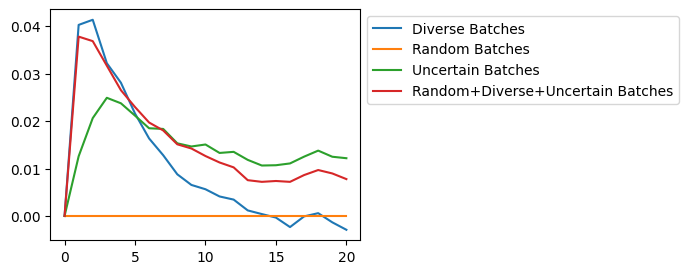

In [11]:
# plt.plot(np.mean(acc_curves_strategies['random'] , axis=0), label='Random')
# for key in acc_curves:
#   plt.plot(np.mean(acc_curves[key], axis=0), label=key)
for key in acc_curves:
    plt.plot(np.mean(acc_curves[key], axis=0) - np.mean(acc_curves['Random Batches'], axis=0) , label=key)
plt.legend(bbox_to_anchor=(1, 1))
plt.savefig(f'plots/{dataset}_batches_ablation.pdf', bbox_inches='tight')

## Look-Ahead

In [6]:
from collections import defaultdict
runs = []

dataset = 'cifar10'
exp_name = 'look_ahead_v1'
uri = 'sqlite:////home/dhuseljic/mlflow/perf_dal/optimal.db' 

client = mlflow.tracking.MlflowClient(tracking_uri=uri)

# experiment_id = client.get_experiment_by_name('optimal_v3').experiment_id
# query_list = [f"parameter.al.strategy = 'random'", f"parameter.dataset_name= '{dataset}'",]
# runs_random = client.search_runs(experiment_ids=experiment_id, filter_string=' and '.join(query_list))
# runs.extend(runs_random)

# experiment_id = client.get_experiment_by_name('optimal_v1').experiment_id
# query_list = [f"parameter.al.strategy = 'typiclust'", f"parameter.dataset_name= '{dataset}'",]
# runs_typiclust = client.search_runs(experiment_ids=experiment_id, filter_string=' and '.join(query_list))
# runs.extend(runs_typiclust)

experiment_id = client.get_experiment_by_name(exp_name).experiment_id
query_list = [
    f"parameter.dataset_name = '{dataset}'", 
]
runs_optimal = client.search_runs(experiment_ids=experiment_id, filter_string=' and '.join(query_list))
runs.extend(runs_optimal)


runs = filter_by_date(runs, 2024, 10, 24)
print('Found {} experiments'.format(len(runs)))

# Adapt runs 
for run in runs:
    al_strat = run.data.params['al.strategy']
    if al_strat == 'optimal':
        look_ahead = run.data.params['al.optimal.look_ahead']
        run.data.params['al.strategy'] = f'optimal with {look_ahead}'
        # run.data.params['al.strategy'] = 'diverse'


runs_per_strat = defaultdict(list)
acc_curves = defaultdict(list)
for run in runs:
    key = run.data.params['al.strategy']
    runs_per_strat[key].append(run)
    acc_curves[key].append([m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')])

for key in  acc_curves:
    print(f"{key:10}: {len(acc_curves[key]):3}")

Found 100 experiments
optimal with mc_labels:  20
optimal with pseudo_labels:  20
optimal with true_labels:  20
random    :  20
margin    :  20


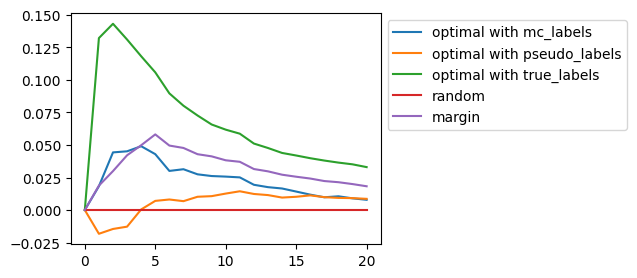

In [ ]:
for key in acc_curves:
    plt.plot(np.mean(acc_curves[key], axis=0) - np.mean(acc_curves['random'], axis=0) , label=key)
plt.legend(bbox_to_anchor=(1, 1))
plt.savefig(f'plots/{dataset}_lookahead_ablation.pdf', bbox_inches='tight')

## Performance Estimation

In [ ]:
from collections import defaultdict
runs = []

dataset = 'cifar10'
exp_name = 'performance_estimation_v1'
uri = 'sqlite:////home/dhuseljic/mlflow/perf_dal/optimal.db' 

client = mlflow.tracking.MlflowClient(tracking_uri=uri)

# experiment_id = client.get_experiment_by_name('optimal_v3').experiment_id
# query_list = [f"parameter.al.strategy = 'random'", f"parameter.dataset_name= '{dataset}'",]
# runs_random = client.search_runs(experiment_ids=experiment_id, filter_string=' and '.join(query_list))
# runs.extend(runs_random)

# experiment_id = client.get_experiment_by_name('optimal_v1').experiment_id
# query_list = [f"parameter.al.strategy = 'typiclust'", f"parameter.dataset_name= '{dataset}'",]
# runs_typiclust = client.search_runs(experiment_ids=experiment_id, filter_string=' and '.join(query_list))
# runs.extend(runs_typiclust)

experiment_id = client.get_experiment_by_name(exp_name).experiment_id
query_list = [
    f"parameter.dataset_name = '{dataset}'", 
    f"parameter.val_split = '1'", 
]
runs_optimal = client.search_runs(experiment_ids=experiment_id, filter_string=' and '.join(query_list))
runs.extend(runs_optimal)


runs = filter_by_date(runs, 2024, 10, 24)
print('Found {} experiments'.format(len(runs)))

# Adapt runs 
for run in runs:
    al_strat = run.data.params['al.strategy']
    if al_strat == 'optimal':
        look_ahead = run.data.params['al.optimal.perf_estimation']
        run.data.params['al.strategy'] = f'{look_ahead}'
        # run.data.params['al.strategy'] = 'diverse'


runs_per_strat = defaultdict(list)
acc_curves = defaultdict(list)
for run in runs:
    key = run.data.params['al.strategy']
    runs_per_strat[key].append(run)
    acc_curves[key].append([m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')])

for key in  acc_curves:
    print(f"{key:15}: {len(acc_curves[key]):3}")

Found 100 experiments
random         :  20
unlabeled_ds   :  20
labeled_ds     :  20
val_ds         :  20
test_ds        :  20


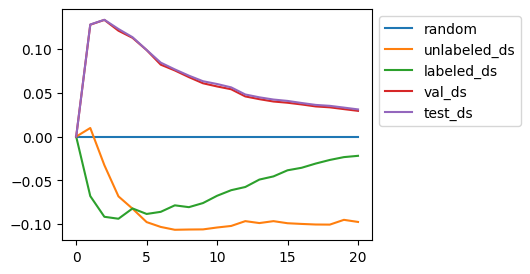

In [ ]:
for key in acc_curves:
    plt.plot(np.mean(acc_curves[key], axis=0) - np.mean(acc_curves['random'], axis=0) , label=key)
plt.legend(bbox_to_anchor=(1, 1))
plt.savefig(f'plots/{dataset}_perf_estimation_ablation.pdf', bbox_inches='tight')

In [3]:
from collections import defaultdict
runs = []

dataset = 'cifar10'
exp_name = 'performance_estimation_v1'
uri = 'sqlite:////home/dhuseljic/mlflow/perf_dal/optimal.db' 

client = mlflow.tracking.MlflowClient(tracking_uri=uri)

experiment_id = client.get_experiment_by_name(exp_name).experiment_id
query_list = [f"parameter.al.strategy = 'random'", f"parameter.dataset_name= '{dataset}'",]
runs_random = client.search_runs(experiment_ids=experiment_id, filter_string=' and '.join(query_list))
runs.extend(runs_random)
runs = filter_by_date(runs, 2024, 11, 19)

# experiment_id = client.get_experiment_by_name('optimal_v1').experiment_id
# query_list = [f"parameter.al.strategy = 'typiclust'", f"parameter.dataset_name= '{dataset}'",]
# runs_typiclust = client.search_runs(experiment_ids=experiment_id, filter_string=' and '.join(query_list))
# runs.extend(runs_typiclust)

experiment_id = client.get_experiment_by_name(exp_name).experiment_id
query_list = [
    f"parameter.dataset_name = '{dataset}'", 
    f"parameter.al.strategy = 'optimal'", 
    f"parameter.al.optimal.perf_estimation = 'val_ds'", 
]
runs_optimal = client.search_runs(experiment_ids=experiment_id, filter_string=' and '.join(query_list))
runs.extend(runs_optimal)


# runs = filter_by_date(runs, 2024, 11, 19)
print('Found {} experiments'.format(len(runs)))

# Adapt runs 
for run in runs:
    al_strat = run.data.params['al.strategy']
    if al_strat == 'optimal':
        val_split = run.data.params['val_split']
        run.data.params['al.strategy'] = f'Val Split: {int(float(val_split)*5000)}'
        # run.data.params['al.strategy'] = 'diverse'


runs_per_strat = defaultdict(list)
acc_curves = defaultdict(list)
for run in runs:
    key = run.data.params['al.strategy']
    runs_per_strat[key].append(run)
    acc_curves[key].append([m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')])

for key in  acc_curves:
    print(f"{key:15}: {len(acc_curves[key]):3}")

Found 161 experiments
random         :  21
Val Split: 100 :  20
Val Split: 10  :  20
Val Split: 20  :  20
Val Split: 50  :  20
Val Split: 2500:  20
Val Split: 500 :  20
Val Split: 5000:  20


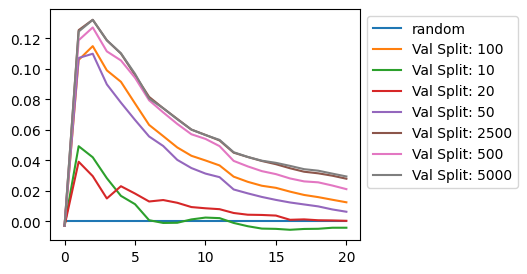

In [4]:
for key in acc_curves:
    plt.plot(np.mean(acc_curves[key], axis=0) - np.mean(acc_curves['random'], axis=0) , label=key)
plt.legend(bbox_to_anchor=(1, 1))
plt.savefig(f'plots/{dataset}_perf_estimation_ablation_valsize.pdf', bbox_inches='tight')

## Retraining

In [2]:
from collections import defaultdict
runs = []

dataset = 'cifar10'
exp_name = 'retraining_v1'
uri = 'sqlite:////home/dhuseljic/mlflow/perf_dal/optimal.db' 

client = mlflow.tracking.MlflowClient(tracking_uri=uri)

experiment_id = client.get_experiment_by_name(exp_name).experiment_id
query_list = [f"parameter.al.strategy = 'random'", f"parameter.dataset_name= '{dataset}'",]
runs_random = client.search_runs(experiment_ids=experiment_id, filter_string=' and '.join(query_list))
runs.extend(runs_random)
# runs = filter_by_date(runs, 2024, 11, 19)

# experiment_id = client.get_experiment_by_name('optimal_v1').experiment_id
# query_list = [f"parameter.al.strategy = 'typiclust'", f"parameter.dataset_name= '{dataset}'",]
# runs_typiclust = client.search_runs(experiment_ids=experiment_id, filter_string=' and '.join(query_list))
# runs.extend(runs_typiclust)

experiment_id = client.get_experiment_by_name(exp_name).experiment_id
query_list = [
    f"parameter.dataset_name = '{dataset}'", 
    f"parameter.al.strategy = 'optimal'", 
]
runs_optimal = client.search_runs(experiment_ids=experiment_id, filter_string=' and '.join(query_list))
runs.extend(runs_optimal)


# runs = filter_by_date(runs, 2024, 11, 19)
print('Found {} experiments'.format(len(runs)))

# Adapt runs 
for run in runs:
    al_strat = run.data.params['al.strategy']
    if al_strat == 'optimal':
        retraining = run.data.params['al.optimal.retraining']
        run.data.params['al.strategy'] = f'{retraining}'

runs_per_strat = defaultdict(list)
acc_curves = defaultdict(list)
for run in runs:
    key = run.data.params['al.strategy']
    runs_per_strat[key].append(run)
    acc_curves[key].append([m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')])

for key in  acc_curves:
    print(f"{key:15}: {len(acc_curves[key]):3}")

Found 60 experiments
random         :  20
train          :  20
update         :  20


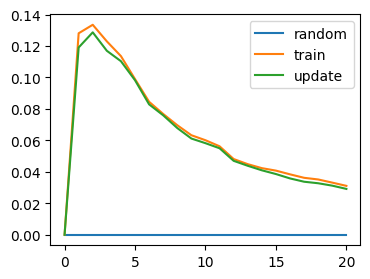

In [4]:
for key in acc_curves:
    plt.plot(np.mean(acc_curves[key], axis=0) - np.mean(acc_curves['random'], axis=0) , label=key)
plt.legend(bbox_to_anchor=(1, 1))
plt.savefig(f'plots/{dataset}_retraining_ablation.pdf', bbox_inches='tight')